# IGRO - análise de sensibilidade dos pesos

Notebook para reproduzir a análise de sensibilidade sugerida na crítica do artigo, com base nas seções `3.5` e `4.6` do texto revisado. O foco aqui é avaliar como diferentes estruturas de ponderação e métodos de agregação alteram os resultados do IGRO por órgão.

## Escopo metodológico

Este notebook implementa três testes principais, alinhados à crítica do artigo e ao material metodológico do projeto:

1. comparação entre três cenários de pesos no nível dos cinco KRIs;
2. comparação entre média geométrica ponderada e média aritmética ponderada;
3. perturbação aleatória dos pesos por bootstrap, com `1.000` iterações e variação de `±10%` antes da renormalização.

Por padrão, o recorte temporal está configurado para `2024-01-01` a `2025-12-31`, para alinhar a análise ao escopo declarado no artigo revisado.

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def encontrar_raiz_projeto(inicio: Path | None = None) -> Path:
    atual = (inicio or Path.cwd()).resolve()
    for candidato in [atual, *atual.parents]:
        if all((candidato / pasta).exists() for pasta in ["06_notebooks", "06_dados", "09_resultados"]):
            return candidato
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto a partir do diretório atual. "
        "Abra o notebook dentro do repositório `igro` ou ajuste manualmente a variável ROOT."
    )


ROOT = encontrar_raiz_projeto()
PASTAS_DADOS = [ROOT / "06_dados" / "01_brutos", ROOT / "02_dados" / "raw"]
SAIDA = ROOT / "09_resultados" / "exportacoes" / "analise_sensibilidade_pesos_igro"
SAIDA.mkdir(parents=True, exist_ok=True)

DATA_INICIO = pd.Timestamp("2024-01-01")
DATA_FIM = pd.Timestamp("2025-12-31")
N_BOOTSTRAP = 1000
SEED = 42

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 10


In [2]:
def escolher_arquivo_mais_recente(prefixo: str) -> Path:
    candidatos: list[Path] = []
    pastas_procuradas: list[str] = []
    for pasta in PASTAS_DADOS:
        pastas_procuradas.append(str(pasta))
        if pasta.exists():
            candidatos.extend(sorted(pasta.glob(f"{prefixo}_*.parquet"), reverse=True))
    if not candidatos:
        candidatos = sorted(ROOT.rglob(f"{prefixo}_*.parquet"), reverse=True)

    erros: list[tuple[str, str]] = []
    for caminho in candidatos:
        try:
            pd.read_parquet(caminho, columns=["Data_manifestacao"]).head(1)
            return caminho
        except Exception as exc:
            erros.append((str(caminho), repr(exc)))

    raise FileNotFoundError(
        f"Nenhum parquet legível encontrado para {prefixo}. "
        f"Pastas verificadas: {pastas_procuradas}. "
        f"Candidatos encontrados: {len(candidatos)}. "
        f"Erros: {erros}"
    )


ARQ_RELATORIO = escolher_arquivo_mais_recente("relatorio")
ARQ_PESQUISA = escolher_arquivo_mais_recente("pesquisa")
ARQ_INSATISFATORIO = escolher_arquivo_mais_recente("insatisfatorio")

ARQ_RELATORIO, ARQ_PESQUISA, ARQ_INSATISFATORIO

(WindowsPath('C:/Users/andre/OneDrive/Claude-Work/Projects/igro/06_dados/01_brutos/relatorio_2026-05-15.parquet'),
 WindowsPath('C:/Users/andre/OneDrive/Claude-Work/Projects/igro/06_dados/01_brutos/pesquisa_2026-05-15.parquet'),
 WindowsPath('C:/Users/andre/OneDrive/Claude-Work/Projects/igro/06_dados/01_brutos/insatisfatorio_2026-05-15.parquet'))

In [3]:
def carregar_bases() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rel = pd.read_parquet(ARQ_RELATORIO)
    pesq = pd.read_parquet(ARQ_PESQUISA)
    ins = pd.read_parquet(ARQ_INSATISFATORIO)
    for df in (rel, pesq, ins):
        df.columns = [c.lower() for c in df.columns]
        df["data_manifestacao"] = pd.to_datetime(df["data_manifestacao"], errors="coerce")
    return rel, pesq, ins


relatorio, pesquisa, insatisfatorio = carregar_bases()

print("Relatório:", ARQ_RELATORIO.name, len(relatorio), "linhas")
print("Pesquisa:", ARQ_PESQUISA.name, len(pesquisa), "linhas")
print("Insatisfatório:", ARQ_INSATISFATORIO.name, len(insatisfatorio), "linhas")

Relatório: relatorio_2026-05-15.parquet 113476 linhas
Pesquisa: pesquisa_2026-05-15.parquet 10930 linhas
Insatisfatório: insatisfatorio_2026-05-15.parquet 1654 linhas


## 1. Construção da base analítica por órgão

A base abaixo calcula os cinco KRIs em nível de órgão, normaliza cada indicador e prepara os scores para a análise de sensibilidade.

In [4]:
def filtrar_periodo(df: pd.DataFrame, inicio: pd.Timestamp, fim: pd.Timestamp) -> pd.DataFrame:
    return df[(df["data_manifestacao"] >= inicio) & (df["data_manifestacao"] <= fim)].copy()


def calcular_kri_orgao(rel: pd.DataFrame, pesq: pd.DataFrame, ins: pd.DataFrame) -> pd.DataFrame:
    rel = rel.copy()
    pesq = pesq.copy()
    ins = ins.copy()

    rel["dias_vida"] = pd.to_numeric(rel.get("dias_vida"), errors="coerce")
    status = rel.get("ds_status", pd.Series(index=rel.index, dtype="object")).fillna("")
    finalizadas = rel[status.str.lower() != "em aberto"].copy()
    finalizadas["tipo_manifestacao"] = finalizadas.get("tipo_manifestacao", pd.Series(index=finalizadas.index, dtype="object")).fillna("")

    base_rel = (
        finalizadas.groupby("sigla", dropna=True)
        .agg(
            total_finalizadas=("protocolo", "count"),
            tmr=("dias_vida", "mean"),
            qtd_pma=("dias_vida", lambda s: (s >= 30).sum()),
            qtd_lai=("tipo_manifestacao", lambda s: (s == "L.A.I.").sum()),
        )
        .reset_index()
    )
    base_rel["elegiveis"] = base_rel["total_finalizadas"] - base_rel["qtd_lai"]
    base_rel["pma"] = base_rel["qtd_pma"] / base_rel["total_finalizadas"]

    resposta = pesq.get("finalizacao", pd.Series(index=pesq.index, dtype="object")).fillna("").astype(str).str.strip().str.lower()
    pesq["sim"] = (resposta == "sim").astype(int)
    pesq["parcial"] = (resposta == "parcialmente").astype(int)
    pesq["recomendaria"] = pd.to_numeric(pesq.get("recomendaria"), errors="coerce")

    base_pesq = (
        pesq.groupby("sigla", dropna=True)
        .agg(
            qtd_pesquisas=("protocolo", "count"),
            qtd_sim=("sim", "sum"),
            qtd_parcial=("parcial", "sum"),
            nr=("recomendaria", "mean"),
        )
        .reset_index()
    )
    base_pesq["rp"] = (base_pesq["qtd_sim"] + 0.5 * base_pesq["qtd_parcial"]) / base_pesq["qtd_pesquisas"]

    base_ins = (
        ins.groupby("sigla", dropna=True)
        .agg(qtd_ri=("protocolo", "count"))
        .reset_index()
    )

    base = base_rel.merge(base_pesq[["sigla", "qtd_pesquisas", "rp", "nr"]], on="sigla", how="left")
    base = base.merge(base_ins, on="sigla", how="left")
    base["qtd_ri"] = base["qtd_ri"].fillna(0)
    base["ri"] = base["qtd_ri"] / base["elegiveis"]

    base = base.replace([np.inf, -np.inf], np.nan)
    base = base.dropna(subset=["tmr", "pma", "rp", "ri", "nr"]).copy()

    base["score_tmr"] = ((10.0 - base["tmr"]) / (10.0 - 5.0)).clip(0, 1)
    base["score_pma"] = ((0.02 - base["pma"]) / (0.02 - 0.01)).clip(0, 1)
    base["score_rp"] = ((base["rp"] - 0.50) / (0.70 - 0.50)).clip(0, 1)
    base["score_ri"] = ((0.035 - base["ri"]) / (0.035 - 0.025)).clip(0, 1)
    base["score_nr"] = ((base["nr"] - 6.0) / (8.0 - 6.0)).clip(0, 1)
    return base.sort_values("sigla").reset_index(drop=True)


rel_filtrado = filtrar_periodo(relatorio, DATA_INICIO, DATA_FIM)
pesq_filtrado = filtrar_periodo(pesquisa, DATA_INICIO, DATA_FIM)
ins_filtrado = filtrar_periodo(insatisfatorio, DATA_INICIO, DATA_FIM)

base_orgao = calcular_kri_orgao(rel_filtrado, pesq_filtrado, ins_filtrado)
base_orgao.head()

,sigla,total_finalizadas,tmr,qtd_pma,qtd_lai,elegiveis,pma,qtd_pesquisas,rp,nr,qtd_ri,ri,score_tmr,score_pma,score_rp,score_ri,score_nr
0,ABC,38,6.947368,0,0,38,0.000000,7.0,0.857143,10.0,2.0,0.052632,0.610526,1.0,1.000000,0.0,1.0
1,AGEHAB,4870,7.663450,122,0,4870,0.025051,111.0,0.391892,5.891892,32.0,0.006571,0.467310,0.0,0.000000,1.0,0.0
2,AGR,5717,7.470002,3,0,5717,0.000525,284.0,0.633803,7.419014,25.0,0.004373,0.506000,1.0,0.669014,1.0,0.709507
3,AGRODEFESA,210,7.895238,1,0,210,0.004762,15.0,0.733333,8.666667,2.0,0.009524,0.420952,1.0,1.000000,1.0,1.0
4,CBM,288,6.361111,0,0,288,0.000000,25.0,0.660000,8.24,3.0,0.010417,0.727778,1.0,0.800000,1.0,1.0


In [5]:
resumo_base = pd.DataFrame(
    {
        "indicador": [
            "Órgãos com base válida",
            "Manifestações finalizadas",
            "Pesquisas válidas",
            "Insatisfatórias válidas",
        ],
        "valor": [
            int(base_orgao["sigla"].nunique()),
            int(base_orgao["total_finalizadas"].sum()),
            int(base_orgao["qtd_pesquisas"].sum()),
            int(base_orgao["qtd_ri"].sum()),
        ],
    }
)
resumo_base

,indicador,valor
0,Órgãos com base válida,47
1,Manifestações finalizadas,93673
2,Pesquisas válidas,9073
3,Insatisfatórias válidas,1365


## 2. Cenários de pesos

Os cenários abaixo seguem a formulação proposta na crítica aplicada ao artigo:

- `Uniforme`: `0,20` para cada KRI;
- `Qualidade`: maior peso em `RP`, `NR` e `%RI`;
- `Tempestividade`: maior peso em `TMR` e `PMA`.

Também incluímos, como referência adicional do projeto, um cenário `Desenho Técnico`, baseado nos pesos documentados em `10_Desenho_IGRO.md`.

In [6]:
SCORES = ["score_tmr", "score_pma", "score_rp", "score_ri", "score_nr"]
ROTULOS_SCORES = {
    "score_tmr": "TMR",
    "score_pma": "PMA",
    "score_rp": "RP",
    "score_ri": "%RI",
    "score_nr": "NR",
}

CENARIOS = {
    "uniforme": {"score_tmr": 0.20, "score_pma": 0.20, "score_rp": 0.20, "score_ri": 0.20, "score_nr": 0.20},
    "qualidade": {"score_tmr": 0.15, "score_pma": 0.15, "score_rp": 0.25, "score_ri": 0.20, "score_nr": 0.25},
    "tempestividade": {"score_tmr": 0.25, "score_pma": 0.25, "score_rp": 0.20, "score_ri": 0.15, "score_nr": 0.15},
    "desenho_tecnico": {"score_tmr": 0.25, "score_pma": 0.15, "score_rp": 0.25, "score_ri": 0.15, "score_nr": 0.20},
}

pesos_df = pd.DataFrame(CENARIOS).rename(index=ROTULOS_SCORES)
pesos_df

,uniforme,qualidade,tempestividade,desenho_tecnico
TMR,0.2,0.15,0.25,0.25
PMA,0.2,0.15,0.25,0.15
RP,0.2,0.25,0.20,0.25
%RI,0.2,0.20,0.15,0.15
NR,0.2,0.25,0.15,0.20


## 3. Funções de agregação e classificação

In [7]:
def agregar_geom(df: pd.DataFrame, pesos: dict[str, float]) -> pd.Series:
    pesos_norm = np.array([pesos[k] for k in SCORES], dtype=float)
    pesos_norm = pesos_norm / pesos_norm.sum()
    valores = np.clip(df[SCORES].to_numpy(dtype=float), 1e-12, 1.0)
    log_igro = np.sum(np.log(valores) * pesos_norm, axis=1)
    return pd.Series(np.exp(log_igro), index=df.index)


def agregar_arit(df: pd.DataFrame, pesos: dict[str, float]) -> pd.Series:
    pesos_norm = np.array([pesos[k] for k in SCORES], dtype=float)
    pesos_norm = pesos_norm / pesos_norm.sum()
    valores = df[SCORES].to_numpy(dtype=float)
    return pd.Series(valores @ pesos_norm, index=df.index)


def classificar_semaforo(valor: float) -> str:
    if valor >= 0.80:
        return "Baixo"
    if valor >= 0.60:
        return "Moderado"
    if valor >= 0.40:
        return "Alto"
    return "Crítico"


def aplicar_cenario(df: pd.DataFrame, nome: str, pesos: dict[str, float], metodo: str = "geom") -> pd.DataFrame:
    base = df.copy()
    if metodo == "geom":
        base[f"igro_{nome}_{metodo}"] = agregar_geom(base, pesos)
    elif metodo == "arit":
        base[f"igro_{nome}_{metodo}"] = agregar_arit(base, pesos)
    else:
        raise ValueError(f"Método inválido: {metodo}")
    col = f"igro_{nome}_{metodo}"
    base[f"classe_{nome}_{metodo}"] = base[col].apply(classificar_semaforo)
    base[f"rank_{nome}_{metodo}"] = base[col].rank(ascending=False, method="min")
    return base


## 4. Teste 1 — variação de pesos

In [8]:
resultados_pesos = base_orgao[["sigla"]].copy()
for nome, pesos in CENARIOS.items():
    igro = agregar_geom(base_orgao, pesos)
    resultados_pesos[f"igro_{nome}"] = igro
    resultados_pesos[f"classe_{nome}"] = igro.apply(classificar_semaforo)

resultados_pesos["variacao_max_pp"] = (
    resultados_pesos[["igro_uniforme", "igro_qualidade", "igro_tempestividade"]].max(axis=1)
    - resultados_pesos[["igro_uniforme", "igro_qualidade", "igro_tempestividade"]].min(axis=1)
) * 100

colunas_visao = [
    "sigla",
    "igro_uniforme",
    "igro_qualidade",
    "igro_tempestividade",
    "variacao_max_pp",
]
comparacao_cenarios = resultados_pesos[colunas_visao].copy()
for c in ["igro_uniforme", "igro_qualidade", "igro_tempestividade"]:
    comparacao_cenarios[c] = comparacao_cenarios[c] * 100
comparacao_cenarios = comparacao_cenarios.sort_values("variacao_max_pp", ascending=False)
comparacao_cenarios.head(15).round(2)

,sigla,igro_uniforme,igro_qualidade,igro_tempestividade,variacao_max_pp
8,CODEGO,44.56,54.53,36.40,18.13
34,SEDS,47.15,56.90,39.07,17.83
43,SIC,60.08,68.24,52.89,15.35
12,EMATER,66.56,73.69,60.12,13.57
9,DETRAN,54.64,46.97,56.85,9.87
18,JUCEG,52.46,45.99,55.64,9.64
21,PC,62.90,56.36,65.19,8.84
3,AGRODEFESA,84.11,87.83,80.55,7.28
7,CGE,46.52,40.44,47.07,6.63
31,SECTI,86.86,89.97,83.85,6.12


In [9]:
sumario_cenarios = pd.DataFrame(
    {
        "cenário": ["uniforme", "qualidade", "tempestividade", "desenho_tecnico"],
        "média_igro": [resultados_pesos[f"igro_{c}"].mean() for c in ["uniforme", "qualidade", "tempestividade", "desenho_tecnico"]],
        "mediana_igro": [resultados_pesos[f"igro_{c}"].median() for c in ["uniforme", "qualidade", "tempestividade", "desenho_tecnico"]],
        "desvio_padrao": [resultados_pesos[f"igro_{c}"].std() for c in ["uniforme", "qualidade", "tempestividade", "desenho_tecnico"]],
    }
)
sumario_cenarios[["média_igro", "mediana_igro", "desvio_padrao"]] = sumario_cenarios[["média_igro", "mediana_igro", "desvio_padrao"]] * 100
sumario_cenarios.round(2)

,cenário,média_igro,mediana_igro,desvio_padrao
0,uniforme,36.94,43.07,38.98
1,qualidade,37.04,40.44,38.87
2,tempestividade,36.38,36.40,38.66
3,desenho_tecnico,35.73,41.99,37.83


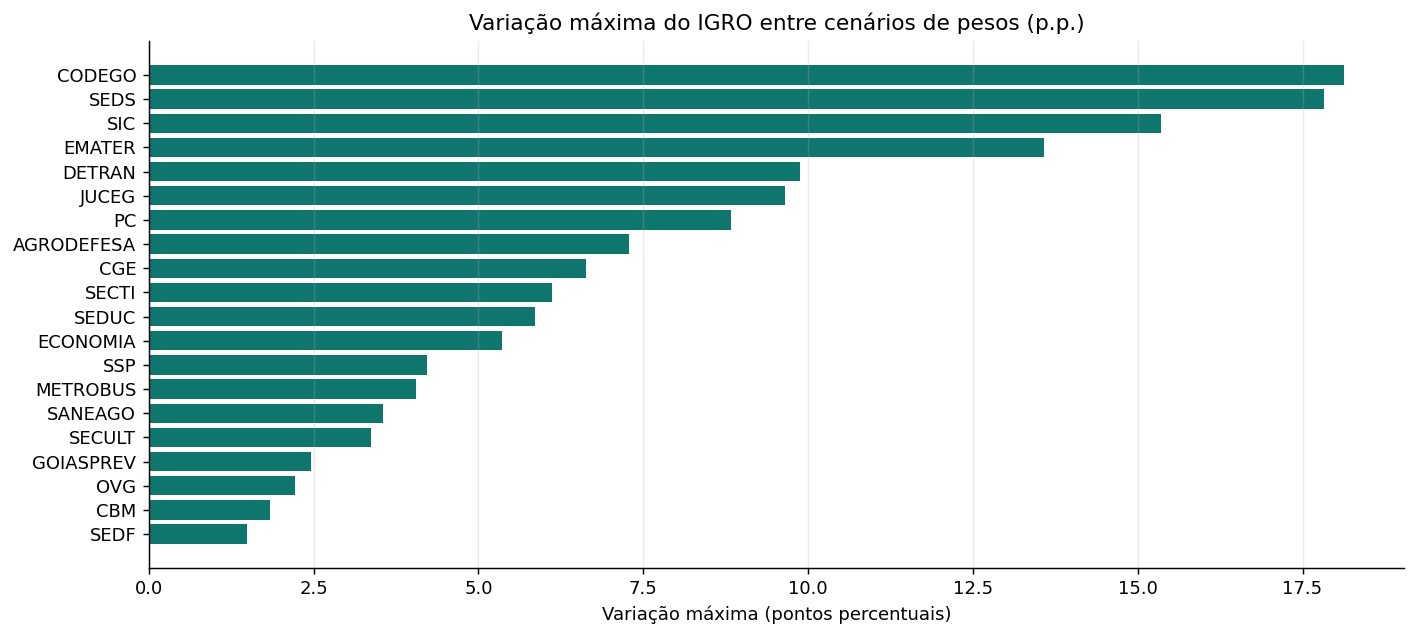

In [10]:
fig, ax = plt.subplots(figsize=(11, 5), facecolor="#ffffff")
plot_df = comparacao_cenarios.head(20).sort_values("variacao_max_pp")
ax.barh(plot_df["sigla"], plot_df["variacao_max_pp"], color="#0f766e")
ax.set_title("Variação máxima do IGRO entre cenários de pesos (p.p.)")
ax.set_xlabel("Variação máxima (pontos percentuais)")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(SAIDA / "sensibilidade_variacao_maxima_cenarios.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Teste 2 — geométrica vs. aritmética

In [11]:
geom_uniforme = agregar_geom(base_orgao, CENARIOS["uniforme"])
arit_uniforme = agregar_arit(base_orgao, CENARIOS["uniforme"])

comparacao_agregacao = base_orgao[["sigla"]].copy()
comparacao_agregacao["igro_geom_uniforme"] = geom_uniforme
comparacao_agregacao["igro_arit_uniforme"] = arit_uniforme
comparacao_agregacao["delta_pp"] = (comparacao_agregacao["igro_arit_uniforme"] - comparacao_agregacao["igro_geom_uniforme"]) * 100
comparacao_agregacao["classe_geom"] = comparacao_agregacao["igro_geom_uniforme"].apply(classificar_semaforo)
comparacao_agregacao["classe_arit"] = comparacao_agregacao["igro_arit_uniforme"].apply(classificar_semaforo)
comparacao_agregacao["mudou_classe"] = comparacao_agregacao["classe_geom"] != comparacao_agregacao["classe_arit"]

comparacao_agregacao.sort_values("delta_pp", ascending=False).head(15).assign(
    igro_geom_uniforme=lambda d: d["igro_geom_uniforme"] * 100,
    igro_arit_uniforme=lambda d: d["igro_arit_uniforme"] * 100,
).round(2)

,sigla,igro_geom_uniforme,igro_arit_uniforme,delta_pp,classe_geom,classe_arit,mudou_classe
33,SEDF,0.40,80.00,79.60,Crítico,Baixo,True
27,SEAPA,0.37,74.29,73.91,Crítico,Moderado,True
23,PM,0.37,74.05,73.68,Crítico,Moderado,True
37,SEINFRA,0.37,73.29,72.92,Crítico,Moderado,True
0,ABC,0.36,72.21,71.85,Crítico,Moderado,True
30,SECOM,0.32,67.20,66.88,Crítico,Moderado,True
17,IQUEGO,0.31,65.90,65.59,Crítico,Moderado,True
29,SECC,0.00,60.00,60.00,Crítico,Moderado,True
24,PREVCOM-BrC,0.00,60.00,60.00,Crítico,Moderado,True
6,CELGPAR,0.00,60.00,60.00,Crítico,Moderado,True


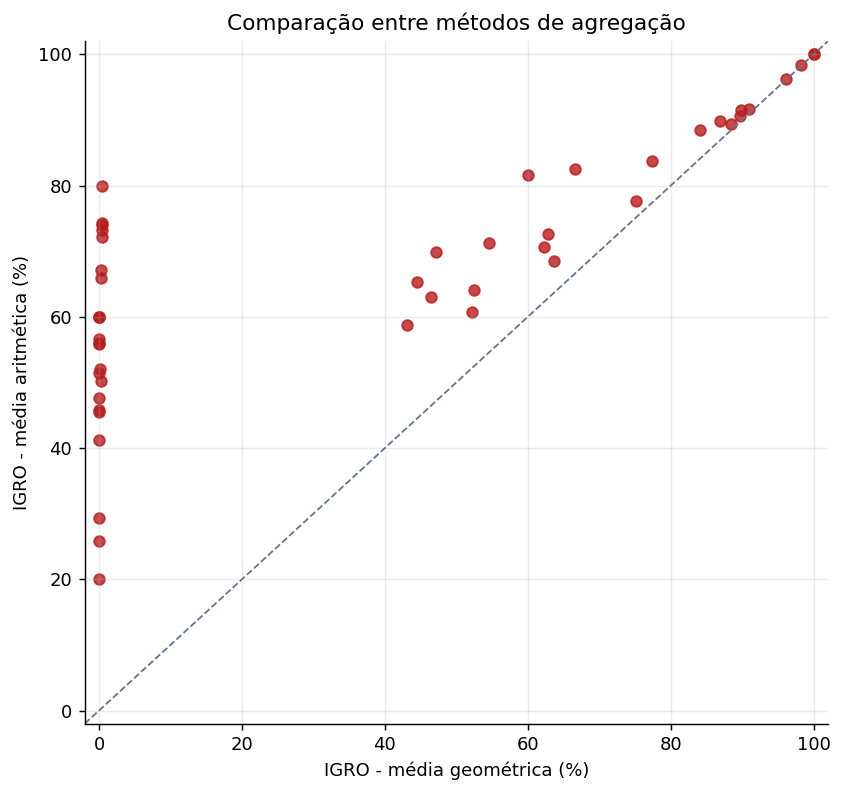

In [12]:
fig, ax = plt.subplots(figsize=(6.6, 6.2), facecolor="#ffffff")
x = comparacao_agregacao["igro_geom_uniforme"] * 100
y = comparacao_agregacao["igro_arit_uniforme"] * 100
ax.scatter(x, y, s=35, color="#b91c1c", alpha=0.8)
lim_inf = min(x.min(), y.min()) - 2
lim_sup = max(x.max(), y.max()) + 2
ax.plot([lim_inf, lim_sup], [lim_inf, lim_sup], linestyle="--", color="#64748b", linewidth=1)
ax.set_xlim(lim_inf, lim_sup)
ax.set_ylim(lim_inf, lim_sup)
ax.set_xlabel("IGRO - média geométrica (%)")
ax.set_ylabel("IGRO - média aritmética (%)")
ax.set_title("Comparação entre métodos de agregação")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(SAIDA / "sensibilidade_geom_vs_arit.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Teste 3 — bootstrap com perturbação dos pesos

In [13]:
rng = np.random.default_rng(SEED)
pesos_base = np.array([CENARIOS["uniforme"][k] for k in SCORES], dtype=float)
valores = np.clip(base_orgao[SCORES].to_numpy(dtype=float), 1e-12, 1.0)

resultados_bootstrap = np.empty((len(base_orgao), N_BOOTSTRAP), dtype=float)
for i in range(N_BOOTSTRAP):
    perturbacao = rng.uniform(0.9, 1.1, size=len(SCORES))
    pesos = pesos_base * perturbacao
    pesos = pesos / pesos.sum()
    log_vals = np.sum(np.log(valores) * pesos, axis=1)
    resultados_bootstrap[:, i] = np.exp(log_vals)

bootstrap_df = pd.DataFrame(
    {
        "sigla": base_orgao["sigla"].to_numpy(),
        "igro_boot_media": resultados_bootstrap.mean(axis=1),
        "igro_boot_p05": np.quantile(resultados_bootstrap, 0.05, axis=1),
        "igro_boot_p50": np.quantile(resultados_bootstrap, 0.50, axis=1),
        "igro_boot_p95": np.quantile(resultados_bootstrap, 0.95, axis=1),
        "amplitude_pp": (np.quantile(resultados_bootstrap, 0.95, axis=1) - np.quantile(resultados_bootstrap, 0.05, axis=1)) * 100,
        "igro_uniforme": geom_uniforme.to_numpy(),
    }
)
bootstrap_df.sort_values("amplitude_pp", ascending=False).head(15).assign(
    igro_boot_media=lambda d: d["igro_boot_media"] * 100,
    igro_boot_p05=lambda d: d["igro_boot_p05"] * 100,
    igro_boot_p50=lambda d: d["igro_boot_p50"] * 100,
    igro_boot_p95=lambda d: d["igro_boot_p95"] * 100,
).round(2)

,sigla,igro_boot_media,igro_boot_p05,igro_boot_p50,igro_boot_p95,amplitude_pp,igro_uniforme
43,SIC,60.09,57.39,60.09,62.63,5.24,0.60
12,EMATER,66.57,64.17,66.57,68.81,4.64,0.67
34,SEDS,47.15,44.93,47.15,49.35,4.42,0.47
9,DETRAN,54.66,52.70,54.65,56.63,3.93,0.55
8,CODEGO,44.56,42.71,44.55,46.44,3.73,0.45
7,CGE,46.54,44.71,46.58,48.36,3.65,0.47
32,SECULT,43.10,41.35,43.08,44.84,3.49,0.43
18,JUCEG,52.47,50.89,52.44,54.03,3.14,0.52
21,PC,62.91,61.35,62.93,64.47,3.13,0.63
44,SSP,62.34,60.91,62.35,63.77,2.86,0.62


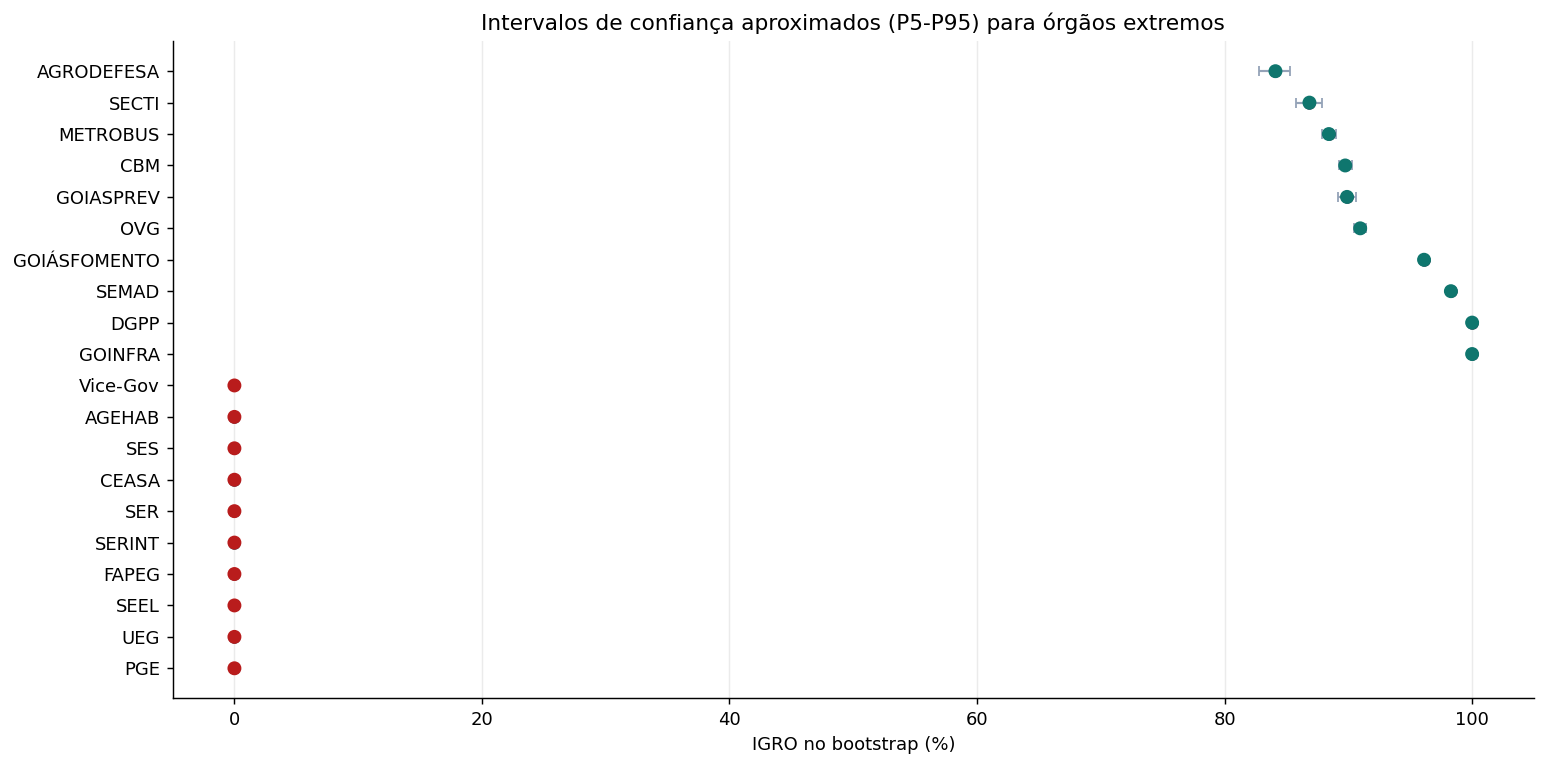

In [14]:
top10 = bootstrap_df.nsmallest(10, "igro_uniforme").copy()
bottom10 = bootstrap_df.nlargest(10, "igro_uniforme").copy()
extremos = pd.concat([top10.assign(grupo="menores"), bottom10.assign(grupo="maiores")], ignore_index=True)
extremos = extremos.sort_values(["grupo", "igro_uniforme"])

fig, ax = plt.subplots(figsize=(12, 6), facecolor="#ffffff")
ypos = np.arange(len(extremos))
media = extremos["igro_boot_media"] * 100
err_low = media - extremos["igro_boot_p05"] * 100
err_high = extremos["igro_boot_p95"] * 100 - media
cores = ["#0f766e" if g == "maiores" else "#b91c1c" for g in extremos["grupo"]]
ax.errorbar(media, ypos, xerr=[err_low, err_high], fmt="o", color="#334155", ecolor="#94a3b8", elinewidth=1.2, capsize=3)
ax.scatter(media, ypos, c=cores, s=45, zorder=3)
ax.set_yticks(ypos)
ax.set_yticklabels(extremos["sigla"])
ax.invert_yaxis()
ax.set_xlabel("IGRO no bootstrap (%)")
ax.set_title("Intervalos de confiança aproximados (P5-P95) para órgãos extremos")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(SAIDA / "sensibilidade_bootstrap_extremos.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Gráficos complementares

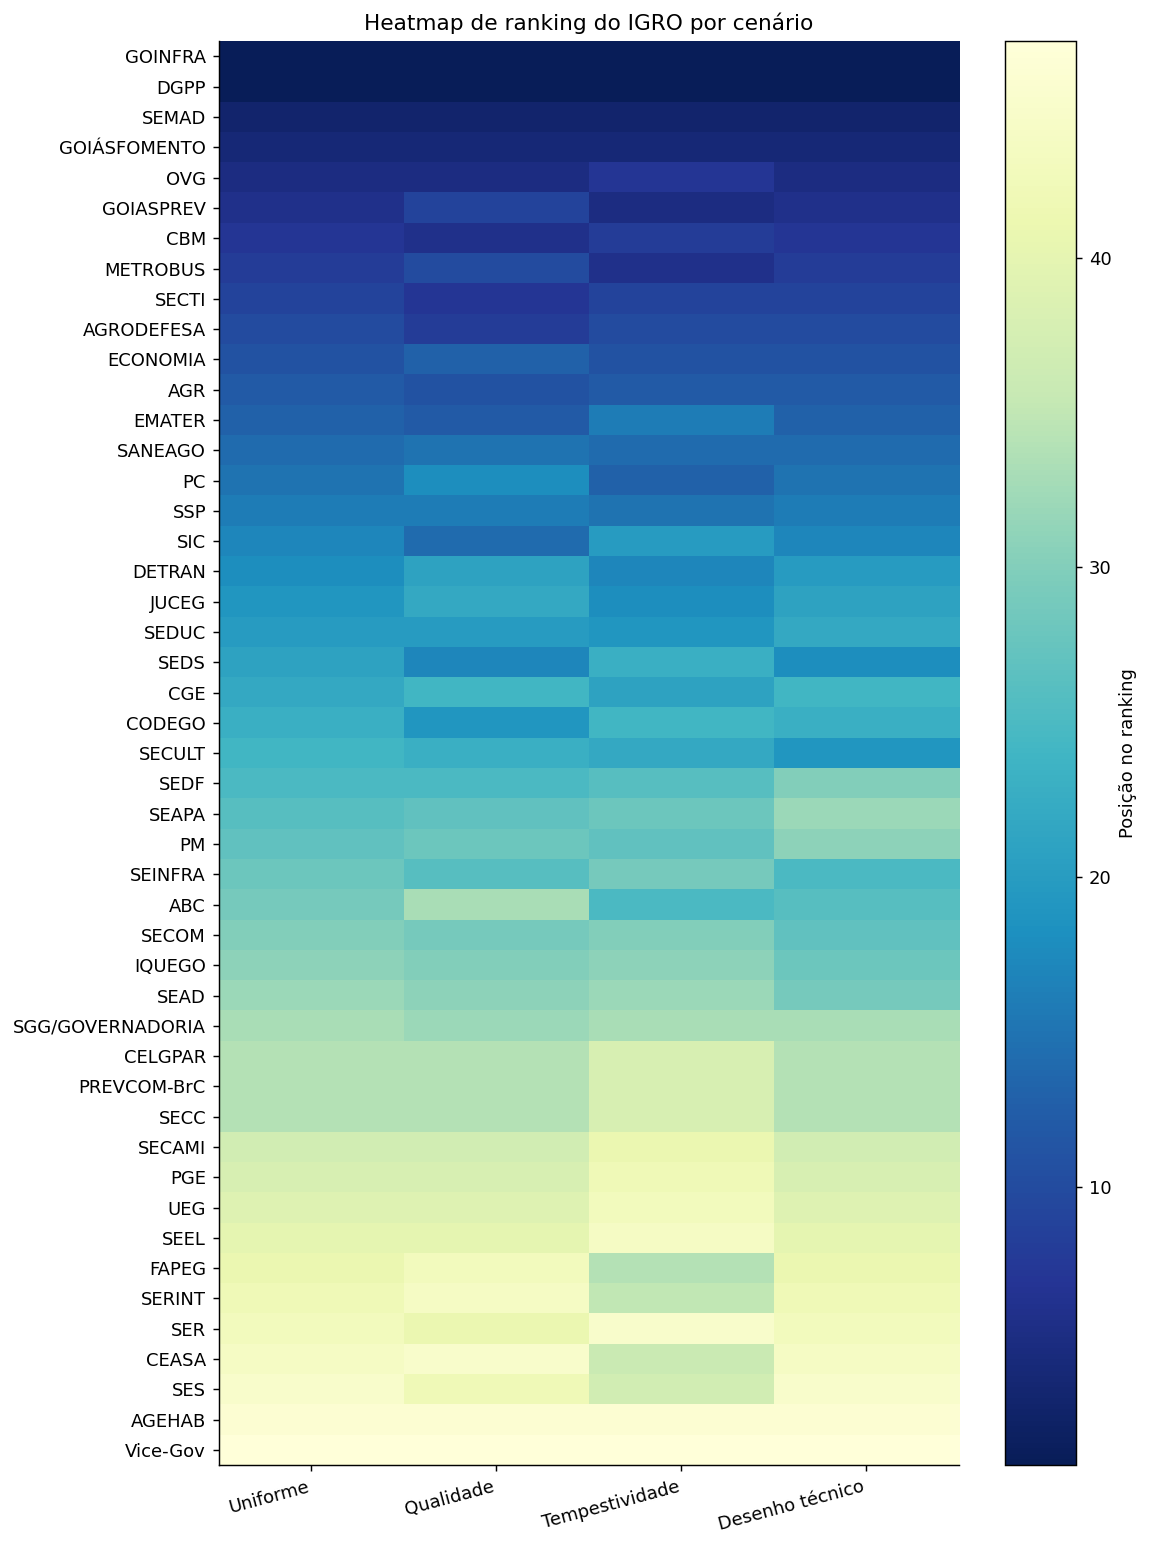

In [15]:
ranking_df = resultados_pesos[["sigla"]].copy()
for nome in ["uniforme", "qualidade", "tempestividade", "desenho_tecnico"]:
    ranking_df[f"rank_{nome}"] = resultados_pesos[f"igro_{nome}"].rank(ascending=False, method="min")

ranking_plot = ranking_df.sort_values("rank_uniforme").set_index("sigla")
matriz_ranking = ranking_plot[["rank_uniforme", "rank_qualidade", "rank_tempestividade", "rank_desenho_tecnico"]].to_numpy()

fig, ax = plt.subplots(figsize=(9, 12), facecolor="#ffffff")
im = ax.imshow(matriz_ranking, aspect="auto", cmap="YlGnBu_r")
ax.set_xticks(range(4))
ax.set_xticklabels(["Uniforme", "Qualidade", "Tempestividade", "Desenho técnico"], rotation=15, ha="right")
ax.set_yticks(range(len(ranking_plot.index)))
ax.set_yticklabels(ranking_plot.index)
ax.set_title("Heatmap de ranking do IGRO por cenário")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Posição no ranking")
fig.tight_layout()
fig.savefig(SAIDA / "sensibilidade_heatmap_rankings.png", dpi=180, bbox_inches="tight")
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_41336\2266295765.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([boxplot_df[c].dropna() for c in boxplot_df.columns], patch_artist=True, labels=boxplot_df.columns)


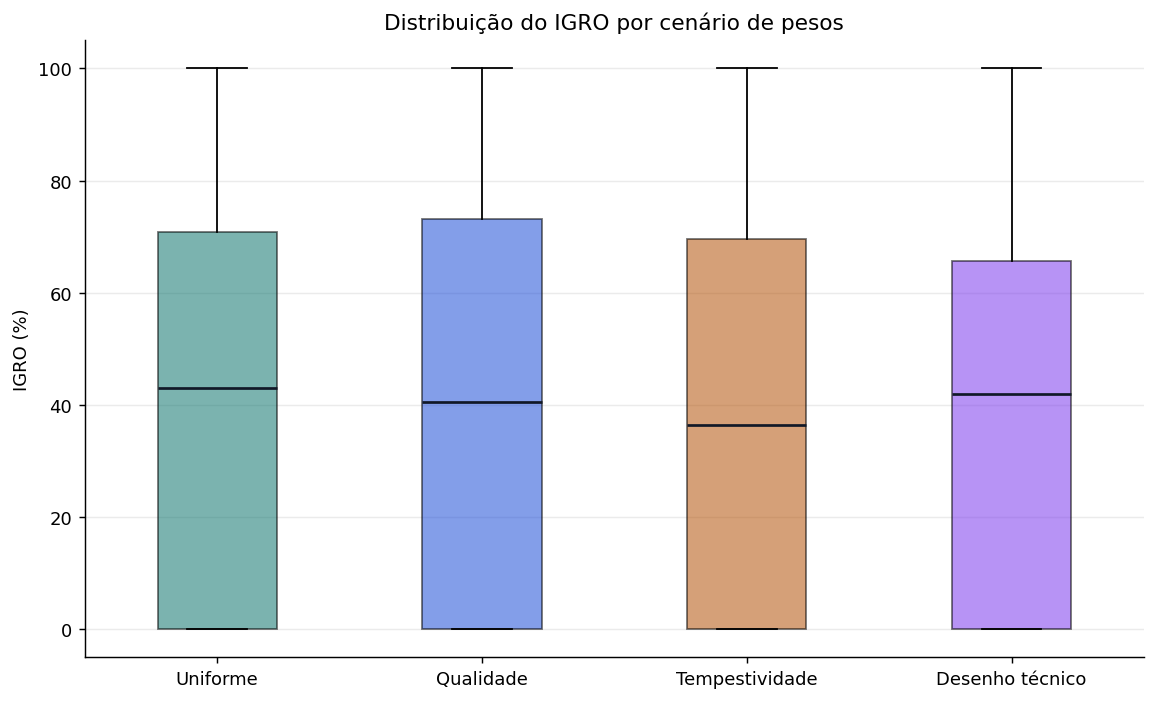

In [16]:
boxplot_df = pd.DataFrame(
    {
        "Uniforme": resultados_pesos["igro_uniforme"] * 100,
        "Qualidade": resultados_pesos["igro_qualidade"] * 100,
        "Tempestividade": resultados_pesos["igro_tempestividade"] * 100,
        "Desenho técnico": resultados_pesos["igro_desenho_tecnico"] * 100,
    }
)

fig, ax = plt.subplots(figsize=(9, 5.5), facecolor="#ffffff")
bp = ax.boxplot([boxplot_df[c].dropna() for c in boxplot_df.columns], patch_artist=True, labels=boxplot_df.columns)
cores = ["#0f766e", "#1d4ed8", "#b45309", "#7c3aed"]
for patch, cor in zip(bp["boxes"], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.55)
for med in bp["medians"]:
    med.set_color("#111827")
    med.set_linewidth(1.5)
ax.set_ylabel("IGRO (%)")
ax.set_title("Distribuição do IGRO por cenário de pesos")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(SAIDA / "sensibilidade_boxplot_cenarios.png", dpi=180, bbox_inches="tight")
plt.show()

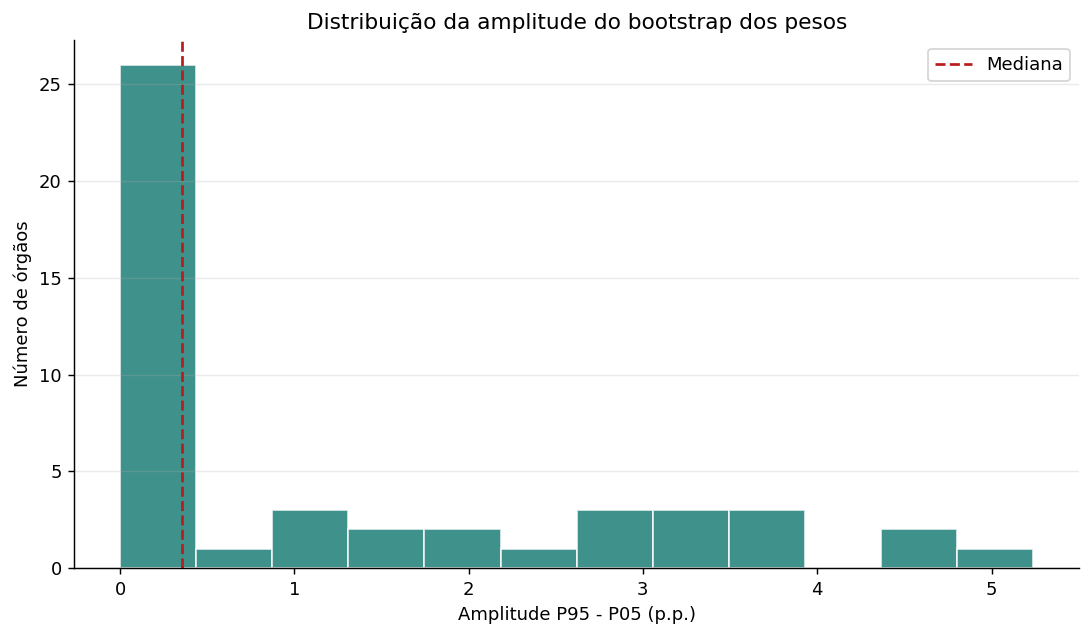

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 5), facecolor="#ffffff")
ax.hist(bootstrap_df["amplitude_pp"], bins=12, color="#0f766e", alpha=0.8, edgecolor="#ffffff")
ax.axvline(bootstrap_df["amplitude_pp"].median(), color="#b91c1c", linestyle="--", linewidth=1.5, label="Mediana")
ax.set_title("Distribuição da amplitude do bootstrap dos pesos")
ax.set_xlabel("Amplitude P95 - P05 (p.p.)")
ax.set_ylabel("Número de órgãos")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(SAIDA / "sensibilidade_hist_bootstrap_amplitude.png", dpi=180, bbox_inches="tight")
plt.show()

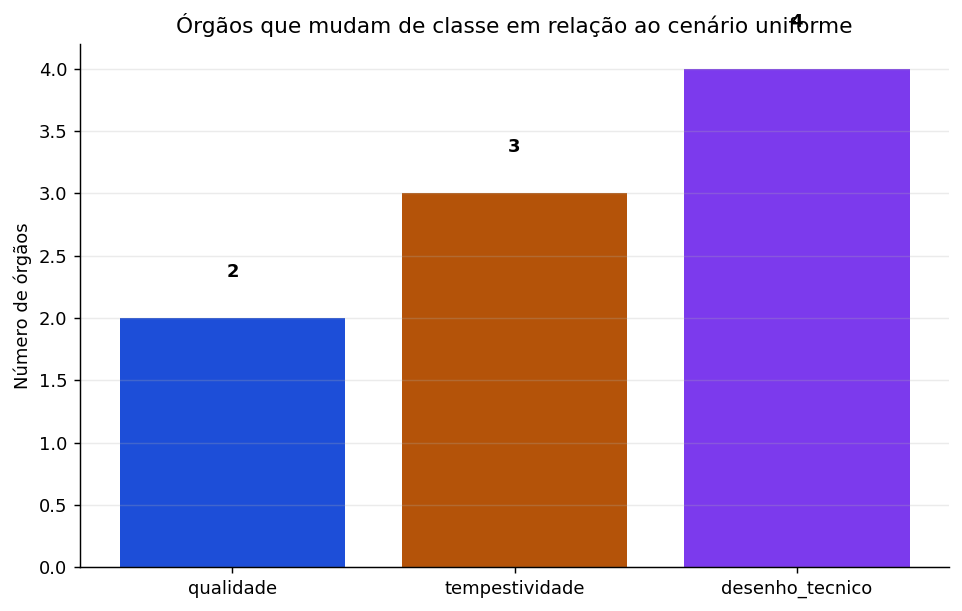

,cenário,orgaos_com_mudanca
0,qualidade,2
1,tempestividade,3
2,desenho_tecnico,4


In [18]:
mudancas_classe = []
base_classe = resultados_pesos["classe_uniforme"]
for nome in ["qualidade", "tempestividade", "desenho_tecnico"]:
    mudou = (base_classe != resultados_pesos[f"classe_{nome}"]).sum()
    mudancas_classe.append({"cenário": nome, "orgaos_com_mudanca": int(mudou)})
mudancas_classe_df = pd.DataFrame(mudancas_classe)

fig, ax = plt.subplots(figsize=(7.5, 4.8), facecolor="#ffffff")
bars = ax.bar(mudancas_classe_df["cenário"], mudancas_classe_df["orgaos_com_mudanca"], color=["#1d4ed8", "#b45309", "#7c3aed"])
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{int(bar.get_height())}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Órgãos que mudam de classe em relação ao cenário uniforme")
ax.set_ylabel("Número de órgãos")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(SAIDA / "sensibilidade_mudanca_classe_cenarios.png", dpi=180, bbox_inches="tight")
plt.show()
mudancas_classe_df

## 8. Exportação dos resultados

In [19]:
base_export = base_orgao.copy()
for col in ["pma", "rp", "ri", "score_tmr", "score_pma", "score_rp", "score_ri", "score_nr"]:
    if col in base_export.columns:
        base_export[col] = base_export[col] * 100

resultados_pesos_export = resultados_pesos.copy()
for col in [c for c in resultados_pesos_export.columns if c.startswith("igro_")]:
    resultados_pesos_export[col] = resultados_pesos_export[col] * 100

comparacao_agregacao_export = comparacao_agregacao.copy()
for col in ["igro_geom_uniforme", "igro_arit_uniforme"]:
    comparacao_agregacao_export[col] = comparacao_agregacao_export[col] * 100

bootstrap_export = bootstrap_df.copy()
for col in ["igro_boot_media", "igro_boot_p05", "igro_boot_p50", "igro_boot_p95", "igro_uniforme"]:
    bootstrap_export[col] = bootstrap_export[col] * 100

base_export.round(4).to_csv(SAIDA / "base_kri_orgao_sensibilidade.csv", index=False, encoding="utf-8-sig")
resultados_pesos_export.round(4).to_csv(SAIDA / "cenarios_pesos_igro.csv", index=False, encoding="utf-8-sig")
comparacao_agregacao_export.round(4).to_csv(SAIDA / "comparacao_geom_vs_arit.csv", index=False, encoding="utf-8-sig")
bootstrap_export.round(4).to_csv(SAIDA / "bootstrap_pesos_igro.csv", index=False, encoding="utf-8-sig")
sumario_cenarios.round(4).to_csv(SAIDA / "sumario_cenarios_pesos.csv", index=False, encoding="utf-8-sig")

pd.DataFrame(
    {
        "artefato": [
            "Base de KRIs por órgão",
            "Resultados dos cenários de pesos",
            "Comparação geométrica vs. aritmética",
            "Bootstrap dos pesos",
            "Sumário dos cenários",
            "Figura variação máxima entre cenários",
            "Figura geométrica vs. aritmética",
            "Figura bootstrap de órgãos extremos",
            "Figura heatmap de rankings",
            "Figura boxplot dos cenários",
            "Figura histograma da amplitude do bootstrap",
            "Figura mudança de classe entre cenários",
        ],
        "caminho": [
            str(SAIDA / "base_kri_orgao_sensibilidade.csv"),
            str(SAIDA / "cenarios_pesos_igro.csv"),
            str(SAIDA / "comparacao_geom_vs_arit.csv"),
            str(SAIDA / "bootstrap_pesos_igro.csv"),
            str(SAIDA / "sumario_cenarios_pesos.csv"),
            str(SAIDA / "sensibilidade_variacao_maxima_cenarios.png"),
            str(SAIDA / "sensibilidade_geom_vs_arit.png"),
            str(SAIDA / "sensibilidade_bootstrap_extremos.png"),
            str(SAIDA / "sensibilidade_heatmap_rankings.png"),
            str(SAIDA / "sensibilidade_boxplot_cenarios.png"),
            str(SAIDA / "sensibilidade_hist_bootstrap_amplitude.png"),
            str(SAIDA / "sensibilidade_mudanca_classe_cenarios.png"),
        ],
    }
)

,artefato,caminho
0,Base de KRIs por órgão,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
1,Resultados dos cenários de pesos,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
2,Comparação geométrica vs. aritmética,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
3,Bootstrap dos pesos,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
4,Sumário dos cenários,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
5,Figura variação máxima entre cenários,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
6,Figura geométrica vs. aritmética,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
7,Figura bootstrap de órgãos extremos,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
8,Figura heatmap de rankings,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
9,Figura boxplot dos cenários,C:\Users\andre\OneDrive\Claude-Work\Projects\i...
